# Graphic 4: The New York Times "Rising Global Temperature" chart

This notebook replicates the chart from the New York Times article
[It's Official: 2018 Was the Fourth-Warmest Year on Record](https://www.nytimes.com/interactive/2019/02/06/climate/fourth-hottest-year.html)
(John Schwartz and Nadja Popovich, Feb. 6, 2019).

The NYT chart is a modified version of Graphic 3:

- every year is a dot connected by a light-grey line;
- values are expressed relative to the **1880-1899 average** ("the late
  19th century"), not the 1951-1980 base period used by NASA;
- the dots are coloured on a blue-to-orange scale centred on the 1951-1980
  anomaly of 0 °C;
- selected years (1904, 1944, 1998, 2016, 2018) are annotated.

To reproduce the original article graphic, the data are restricted to
1880-2018, as in the February 2019 article.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## Load the data and rebase it

The NYT article compares each year with the 1880-1899 average, so the NASA
anomalies (relative to 1951-1980) are shifted by the 1880-1899 mean.

In [2]:
df = pd.read_csv(DATA_DIR / "global_annual_mean.csv", skiprows=2,
                 names=["Year", "No_Smoothing", "Lowess"])
df = df[df.Year <= 2018].copy()

base = df[(df.Year >= 1880) & (df.Year <= 1899)]["No_Smoothing"].mean()
df["Rebased"] = df["No_Smoothing"] - base

print(f"1880-1899 average anomaly (w.r.t. 1951-1980): {base:.4f} C")
df.head()

1880-1899 average anomaly (w.r.t. 1951-1980): -0.2305 C


,Year,No_Smoothing,Lowess,Rebased
0,1880,-0.18,-0.10,0.0505
1,1881,-0.09,-0.14,0.1405
2,1882,-0.12,-0.18,0.1105
3,1883,-0.18,-0.21,0.0505
4,1884,-0.29,-0.25,-0.0595


## Build the figure

The colour scale was approximated from the published graphic: blue for cold
years, a warm off-white around the 1951-1980 anomaly of 0 °C, and orange-red
for the warmest years.

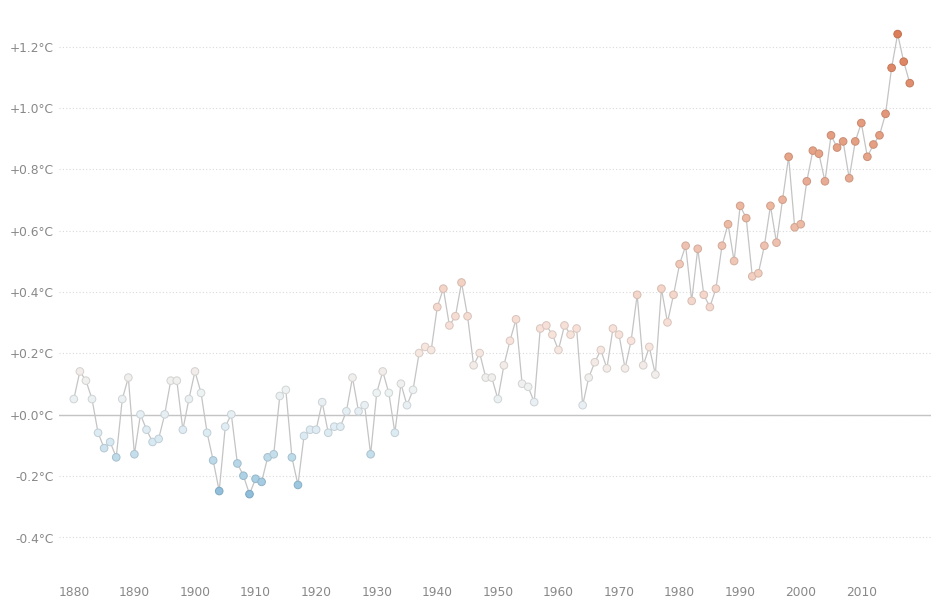

In [3]:
ANCHORS = [
    (-0.55, "#83b7d6"), (-0.48, "#92c0dc"), (-0.44, "#abd0e4"), (-0.38, "#bbd9e9"),
    (-0.32, "#d9eaf3"), (-0.25, "#e3eef4"), (-0.15, "#eef2f2"), (0.00, "#f8e5dd"),
    (0.06, "#f7e0d7"), (0.12, "#f5d9ce"), (0.20, "#f3d3c5"), (0.26, "#f1c8b7"),
    (0.32, "#eec1b0"), (0.39, "#edbaa4"), (0.45, "#ecb6a0"), (0.53, "#e8ac94"),
    (0.62, "#e6a387"), (0.72, "#e49b7e"), (0.85, "#e08e6e"), (0.92, "#df8765"),
    (1.01, "#dc7e5a"), (1.05, "#db7a55"),
]
VMIN, VMAX = -0.55, 1.05
cmap = LinearSegmentedColormap.from_list(
    "nyt", [((v - VMIN) / (VMAX - VMIN), c) for v, c in ANCHORS])
norm = Normalize(VMIN, VMAX)


def edge_color(rgba):
    r, g, b, _ = rgba
    return (r * 0.88, g * 0.88, b * 0.88)


fig = plt.figure(figsize=(9.79, 8.01), dpi=100)
ax = fig.add_axes([0.069, 0.0503, 0.891, 0.716])
ax.set_xlim(1877.55, 2021.55)
ax.set_ylim(-0.55, 1.32)

for v in np.arange(-0.4, 1.2001, 0.2):
    ax.axhline(v, color="#d9d9d9", lw=0.8, ls=(0, (1, 2)), zorder=0)
ax.axhline(0, color="#c4c4c4", lw=1.0, zorder=1)

ax.plot(df.Year, df.Rebased, color="#c4c4c4", lw=0.9, zorder=2)
colors = [cmap(norm(v)) for v in df.No_Smoothing]
ax.scatter(df.Year, df.Rebased, s=30, c=colors,
           edgecolors=[edge_color(c) for c in colors],
           linewidths=0.72, zorder=3)

ax.set_yticks(np.arange(-0.4, 1.2001, 0.2))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:+.1f}\N{DEGREE SIGN}C"))
ax.set_xticks(range(1880, 2019, 10))
ax.tick_params(axis="x", colors="#888888", labelsize=8.8, length=0, pad=2)
ax.tick_params(axis="y", colors="#888888", labelsize=8.8, length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

### Annotations, titles, and source line

In [4]:
ANN = [
    (2016, 1.255, "2016", (2016, 1.31), "center", "bottom"),
    (2018, 1.09, "2018", (2020.5, 1.07), "left", "center"),
    (1998, 0.85, "1998", (1998, 0.99), "center", "bottom"),
    (1944, 0.44, "1944", (1944, 0.57), "center", "bottom"),
    (1904, -0.24, "1904", (1904, -0.37), "center", "top"),
]
for x, y, label, xytext, ha, va in ANN:
    ax.annotate(label, xy=(x, y), xytext=xytext, ha=ha, va=va, fontsize=9,
                color="#555555",
                arrowprops=dict(arrowstyle="-", color="#b0b0b0", lw=0.8,
                                shrinkA=0, shrinkB=2))

ax.text(2021.5, 0.10, "HOTTER THAN THE\n1880-1899 AVERAGE", ha="right",
        va="bottom", fontsize=8.2, color="#777777", linespacing=1.5)
ax.text(2021.5, -0.06, "COLDER", ha="right", va="top",
        fontsize=8.2, color="#777777")

fig.text(0.5, 0.916, "It's Official: 2018 Was the\nFourth-Warmest Year on Record",
         ha="center", va="center", fontsize=22, fontweight="bold",
         family="Georgia", color="#111111", linespacing=1.15)
fig.text(0.5, 0.795, "By JOHN SCHWARTZ and NADJA POPOVICH   FEB. 6, 2019",
         ha="center", va="center", fontsize=8.5, family="Georgia", color="#333333")

ax.text(0.175, 0.824, "Rising Global\nTemperature", transform=ax.transAxes,
        ha="left", va="top", fontsize=15.5, fontweight="bold",
        family="Georgia", color="#222222", linespacing=1.25)
ax.text(0.16, 0.725, "How much cooler or warmer\nevery year was compared with\n"
        "the average temperature of the\nlate 19th century",
        transform=ax.transAxes, ha="left", va="top", fontsize=9.2,
        family="Georgia", color="#555555", linespacing=1.55)

fig.text(0.065, 0.011, "Source: NASA | By The New York Times",
         fontsize=9, color="#888888")
fig.text(0.975, 0.011, "Replication for STAT 159/259", ha="right",
         fontsize=8, color="#bbbbbb")

Text(0.975, 0.011, 'Replication for STAT 159/259')

## Save and display

In [5]:
fig.savefig(OUTPUT_DIR / "graphic4_nyt_rising_global_temperature.png", dpi=100)
fig.savefig(OUTPUT_DIR / "graphic4_nyt_rising_global_temperature.pdf")
plt.show()

The re-based values make the comparison with the late 19th century explicit:
2016 (+1.24 °C) and 2018 (+1.08 °C) are far above the 1880-1899 average,
while 1904 (-0.25 °C) is one of the coldest years. Only the chart itself is
replicated here; the article headline is included for visual context, but the
article text and interactive elements are not.